<a href="https://colab.research.google.com/github/tezendrax/Deep-Learning-Labs/blob/main/DL_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Logistic Regression from Scratch for Binary Classification

### Objectives
- Understand the sigmoid function.
- Implement logistic regression without using a machine-learning library.
- Compute Binary Cross-Entropy (Log) Loss from scratch.
- Derive and implement gradients.
- Train the model using gradient descent.
- Evaluate the classifier.
- Visualize the training loss and the learned decision boundary.

**Note:** Only NumPy and Matplotlib are used for the logistic regression implementation. No ready-made classifier such as `sklearn.linear_model.LogisticRegression` is used.

## 1. Import the required libraries

We will use:
- **NumPy** for numerical computations.
- **Matplotlib** for visualization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Create a binary classification dataset

We create two groups of 2-D points using Gaussian distributions.

- Class 0: centered around one location.
- Class 1: centered around another location.

Using two features allows us to visualize the learned decision boundary.

In [ ]:
# Number of samples in each class
n_samples_per_class = 100

# Class 0
X_class0 = np.random.randn(n_samples_per_class, 2) + np.array([2, 2])

# Class 1
X_class1 = np.random.randn(n_samples_per_class, 2) + np.array([5, 5])

# Combine the two classes
X = np.vstack((X_class0, X_class1))

# Target labels
y = np.hstack((
    np.zeros(n_samples_per_class),
    np.ones(n_samples_per_class)
))

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class 0 samples:", np.sum(y == 0))
print("Class 1 samples:", np.sum(y == 1))

X shape: (200, 2)
y shape: (200,)
Class 0 samples: 100
Class 1 samples: 100


## 3. Visualize the dataset

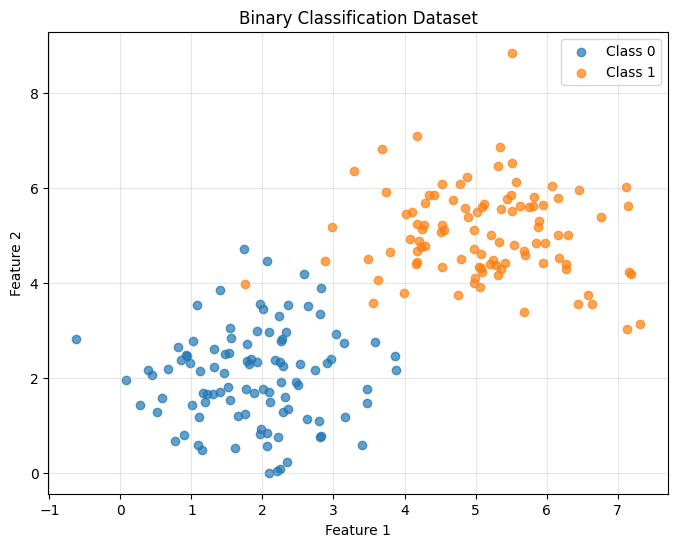

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0",
    alpha=0.7
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1",
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Split the data into training and testing sets

We implement the split ourselves using NumPy so that the lab does not depend on a ready-made machine-learning classifier.

We use:
- 80% training data
- 20% testing data

In [ ]:
# Shuffle the dataset
indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

# 80-20 split
split_index = int(0.8 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


## 5. Feature standardization

Standardization makes gradient descent more stable.

Formula:

$$
x_{scaled} = \frac{x - \mu}{\sigma}
$$

Importantly, the mean and standard deviation are calculated **only from the training data**.

In [ ]:
# Calculate statistics from training data only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# Standardize training and test data
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

print("Training feature mean:", X_train_scaled.mean(axis=0))
print("Training feature std:", X_train_scaled.std(axis=0))

Training feature mean: [ 4.26048086e-16 -1.82492910e-16]
Training feature std: [1. 1.]


## 6. Define the sigmoid function

Logistic regression first calculates a linear combination:

$$
z = Xw + b
$$

The sigmoid function converts this value into a probability:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The output is between 0 and 1.

In [ ]:
def sigmoid(z):
    # Clip z to avoid numerical overflow in exp()
    # z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


# Test the sigmoid function
test_values = np.array([-5, -2, 0, 2, 5])

print("Input :", test_values)
print("Output:", sigmoid(test_values))

Input : [-5 -2  0  2  5]
Output: [0.00669285 0.11920292 0.5        0.88079708 0.99330715]


## 7. Plot the sigmoid function

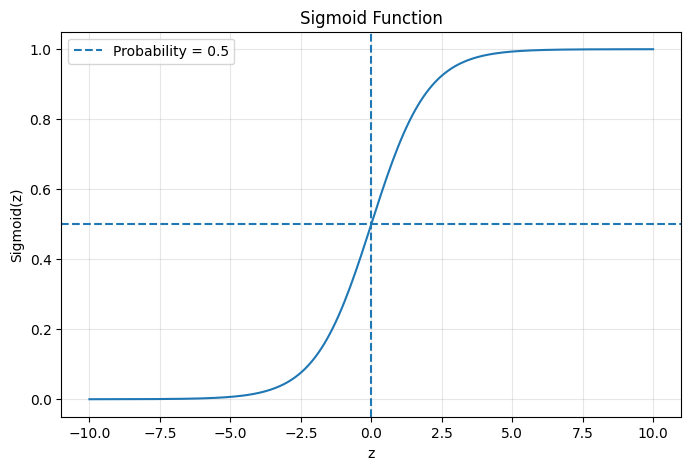

In [ ]:
z_values = np.linspace(-10, 10, 200)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(8, 5))
plt.plot(z_values, sigmoid_values)
plt.axhline(0.5, linestyle="--", label="Probability = 0.5")
plt.axvline(0, linestyle="--")
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Define the Binary Cross-Entropy Loss

For binary classification, the loss for one sample is:

$$
L = -[y\log(\hat{y}) + (1-y)\log(1-\hat{y})]
$$

For all training samples:

$$
J(w,b) =
-\frac{1}{m}
\sum_{i=1}^{m}
[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
]
$$

where:

- $y$ is the actual label.
- $\hat{y}$ is the predicted probability.
- $m$ is the number of training samples.

In [ ]:
def binary_cross_entropy(y_true, y_pred):
    # Avoid log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )

    return loss


# Simple example
y_example = np.array([1, 0, 1, 1])
y_pred_example = np.array([0.9, 0.2, 0.8, 0.6])

loss_example = binary_cross_entropy(y_example, y_pred_example)

print("Binary Cross-Entropy Loss:", loss_example)

Binary Cross-Entropy Loss: 0.2656183105130591


## 9. Initialize logistic regression parameters

The model parameters are:

- $w$: weight vector
- $b$: bias

Initially, we set them to zero.

In [ ]:
n_features = X_train_scaled.shape[1]

w = np.zeros(n_features)
b = 0.0

print("Initial weights:", w)
print("Initial bias:", b)

Initial weights: [0. 0.]
Initial bias: 0.0


## 10. Forward propagation

The logistic regression model performs two steps:

### Step 1: Linear combination

$$
z = Xw + b
$$

### Step 2: Convert to probability

$$
\hat{y} = \sigma(z)
$$

In [ ]:
def predict_probability(X, w, b):
    z = np.dot(X, w) + b
    return sigmoid(z)


# Test forward propagation
initial_probabilities = predict_probability(
    X_train_scaled,
    w,
    b
)

print("First 10 predicted probabilities:")
print(initial_probabilities[:10])

First 10 predicted probabilities:
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


## 11. Derive the gradients

For logistic regression with Binary Cross-Entropy loss:

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}X^T(\hat{y}-y)
$$

and

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}(\hat{y}_i-y_i)
$$

These gradients tell us how the weights and bias should change to reduce the loss.

In [ ]:
def compute_gradients(X, y, y_pred):
    m = len(y)

    error = y_pred - y

    dw = (1 / m) * np.dot(X.T, error)
    db = (1 / m) * np.sum(error)

    return dw, db


# Calculate initial gradients
dw, db = compute_gradients(
    X_train_scaled,
    y_train,
    initial_probabilities
)

print("Gradient of weights:", dw)
print("Gradient of bias:", db)

Gradient of weights: [-0.43051264 -0.41565098]
Gradient of bias: -0.0125


## 12. Train logistic regression using Gradient Descent

Parameter update rules:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

where $\alpha$ is the learning rate.

We store the loss after every iteration so that we can plot the learning curve.

In [ ]:
def train_logistic_regression(X, y, learning_rate=0.1, epochs=1000):
    n_samples, n_features = X.shape

    # Initialize parameters
    w = np.zeros(n_features)
    b = 0.0

    loss_history = []

    for epoch in range(epochs):

        # -------------------------
        # Forward propagation
        # -------------------------
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)

        # -------------------------
        # Compute loss
        # -------------------------
        loss = binary_cross_entropy(y, y_pred)
        loss_history.append(loss)

        # -------------------------
        # Compute gradients
        # -------------------------
        dw, db = compute_gradients(X, y, y_pred)

        # -------------------------
        # Gradient descent update
        # -------------------------
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # Print progress
        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")

    return w, b, loss_history

## 13. Train the model

In [ ]:
learning_rate = 0.1
epochs = 1000

w, b, loss_history = train_logistic_regression(
    X_train_scaled,
    y_train,
    learning_rate=learning_rate,
    epochs=epochs
)

# print("\nFinal weights:", w)
# print("Final bias:", b)

Epoch    0 | Loss: 0.693147
Epoch  100 | Loss: 0.130197
Epoch  200 | Loss: 0.089753
Epoch  300 | Loss: 0.074303
Epoch  400 | Loss: 0.065967
Epoch  500 | Loss: 0.060694
Epoch  600 | Loss: 0.057035
Epoch  700 | Loss: 0.054336
Epoch  800 | Loss: 0.052258
Epoch  900 | Loss: 0.050606


## 14. Plot the training loss

A successful training process should generally show the Cross-Entropy loss decreasing as the number of epochs increases.

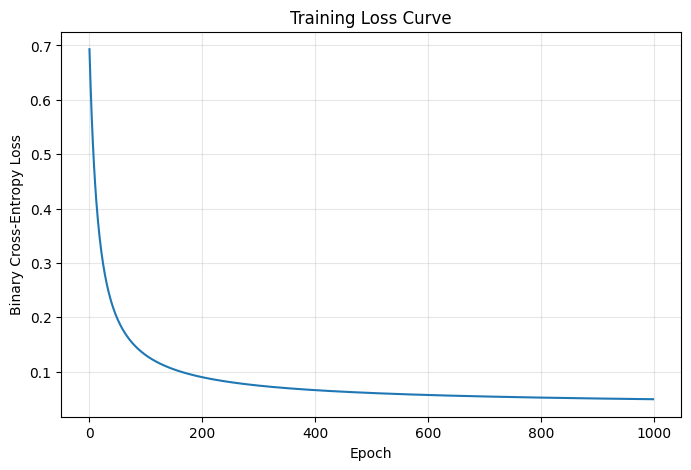

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss Curve")
plt.grid(alpha=0.3)

plt.show()

## 15. Make predictions

The model produces probabilities.

We convert probabilities into class labels using a threshold of 0.5:

$$
\hat{y}_{class} =
\begin{cases}
1 & \text{if } \hat{y} \geq 0.5 \\
0 & \text{otherwise}
\end{cases}
$$

In [ ]:
def predict(X, w, b, threshold=0.5):
    probabilities = predict_probability(X, w, b)
    predictions = (probabilities >= threshold).astype(int)

    return predictions, probabilities


y_train_pred, y_train_prob = predict(
    X_train_scaled,
    w,
    b
)

y_test_pred, y_test_prob = predict(
    X_test_scaled,
    w,
    b
)

print("First 10 test probabilities:")
print(y_test_prob[:10])

print("\nFirst 10 test predictions:")
print(y_test_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test[:10])

First 10 test probabilities:
[9.97225553e-01 3.06301429e-01 9.99844364e-01 1.55805518e-01
 5.81159143e-04 3.99067257e-03 9.18585221e-01 6.36275348e-01
 9.99935210e-01 9.99258980e-01]

First 10 test predictions:
[1 0 1 0 0 0 1 1 1 1]

First 10 actual labels:
[1. 0. 1. 0. 0. 0. 1. 1. 1. 1.]


## 16. Calculate accuracy from scratch

Accuracy is:

$$
Accuracy =
\frac{\text{Number of correct predictions}}
{\text{Total number of predictions}}
$$

In [ ]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


train_accuracy = accuracy(y_train, y_train_pred)
test_accuracy = accuracy(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy : {test_accuracy * 100:.2f}%")

Training Accuracy: 99.38%
Testing Accuracy : 100.00%


## 17. Compute the final Cross-Entropy loss

We calculate the loss separately on the training and testing data.

In [ ]:
train_loss = binary_cross_entropy(y_train, y_train_prob)
test_loss = binary_cross_entropy(y_test, y_test_prob)

print(f"Training Cross-Entropy Loss: {train_loss:.6f}")
print(f"Testing Cross-Entropy Loss : {test_loss:.6f}")

Training Cross-Entropy Loss: 0.049259
Testing Cross-Entropy Loss : 0.040259


## 18. Confusion Matrix from scratch

For binary classification:

- **True Positive (TP):** actual 1, predicted 1
- **True Negative (TN):** actual 0, predicted 0
- **False Positive (FP):** actual 0, predicted 1
- **False Negative (FN):** actual 1, predicted 0

In [ ]:
def confusion_matrix_binary(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    return tn, fp, fn, tp


tn, fp, fn, tp = confusion_matrix_binary(
    y_test,
    y_test_pred
)

print("Confusion Matrix")
print("----------------")
print(f"True Negative  (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive  (TP): {tp}")

Confusion Matrix
----------------
True Negative  (TN): 22
False Positive (FP): 0
False Negative (FN): 0
True Positive  (TP): 18


## 19. Visualize the confusion matrix

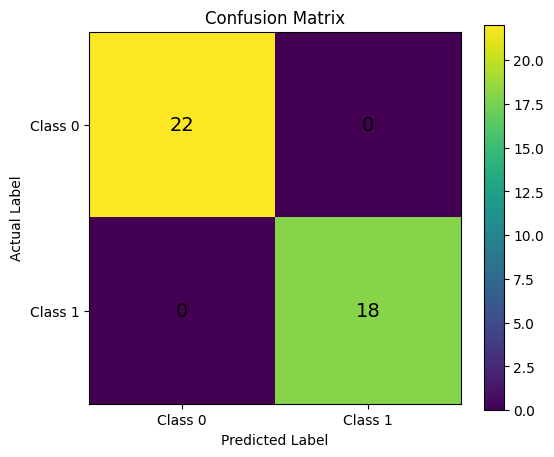

In [ ]:
cm = np.array([
    [tn, fp],
    [fn, tp]
])

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar()
plt.show()

## 20. Plot the learned decision boundary

The logistic regression decision boundary occurs when:

$$
P(y=1|x)=0.5
$$

Since:

$$
\sigma(z)=0.5 \Rightarrow z=0
$$

the decision boundary is:

$$
w_1x_1+w_2x_2+b=0
$$

For standardized features, we plot the boundary in the standardized feature space.

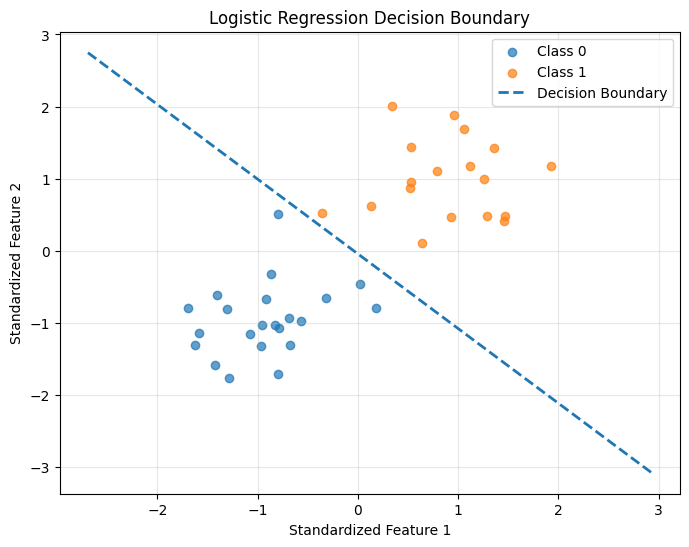

In [ ]:
plt.figure(figsize=(8, 6))

# Plot test samples
plt.scatter(
    X_test_scaled[y_test == 0, 0],
    X_test_scaled[y_test == 0, 1],
    label="Class 0",
    alpha=0.7
)

plt.scatter(
    X_test_scaled[y_test == 1, 0],
    X_test_scaled[y_test == 1, 1],
    label="Class 1",
    alpha=0.7
)

# Create x-axis values for decision boundary
x1_values = np.linspace(
    X_test_scaled[:, 0].min() - 1,
    X_test_scaled[:, 0].max() + 1,
    200
)

# w1*x1 + w2*x2 + b = 0
# Therefore:
# x2 = -(w1*x1 + b) / w2
x2_values = -(w[0] * x1_values + b) / w[1]

plt.plot(
    x1_values,
    x2_values,
    linestyle="--",
    linewidth=2,
    label="Decision Boundary"
)

plt.xlabel("Standardized Feature 1")
plt.ylabel("Standardized Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 21. Visualize predicted probabilities

The color/intensity of the points represents the probability predicted by the model for Class 1.

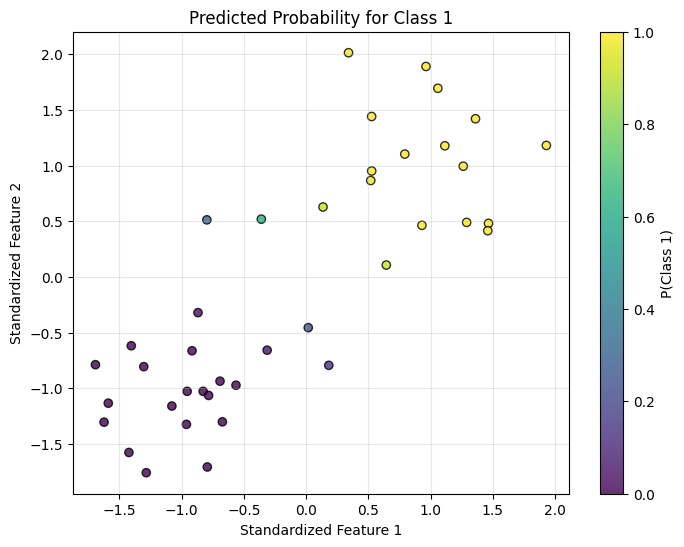

In [ ]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_test_scaled[:, 0],
    X_test_scaled[:, 1],
    c=y_test_prob,
    cmap="viridis",
    vmin=0,
    vmax=1,
    edgecolor="k",
    alpha=0.8
)

plt.colorbar(scatter, label="P(Class 1)")
plt.xlabel("Standardized Feature 1")
plt.ylabel("Standardized Feature 2")
plt.title("Predicted Probability for Class 1")
plt.grid(alpha=0.3)

plt.show()

## 22. Experiment: Change the learning rate

Try different learning rates and compare the loss curves.

This helps demonstrate the effect of the learning rate on gradient descent.

Epoch    0 | Loss: 0.693147
Epoch  100 | Loss: 0.658788
Epoch  200 | Loss: 0.627213
Epoch  300 | Loss: 0.598179
Epoch  400 | Loss: 0.571462
Epoch    0 | Loss: 0.693147
Epoch  100 | Loss: 0.448828
Epoch  200 | Loss: 0.332039
Epoch  300 | Loss: 0.266814
Epoch  400 | Loss: 0.225719
Epoch    0 | Loss: 0.693147
Epoch  100 | Loss: 0.130197
Epoch  200 | Loss: 0.089753
Epoch  300 | Loss: 0.074303
Epoch  400 | Loss: 0.065967
Epoch    0 | Loss: 0.693147
Epoch  100 | Loss: 0.227114
Epoch  200 | Loss: 0.185443
Epoch  300 | Loss: 0.072587
Epoch  400 | Loss: 0.076885


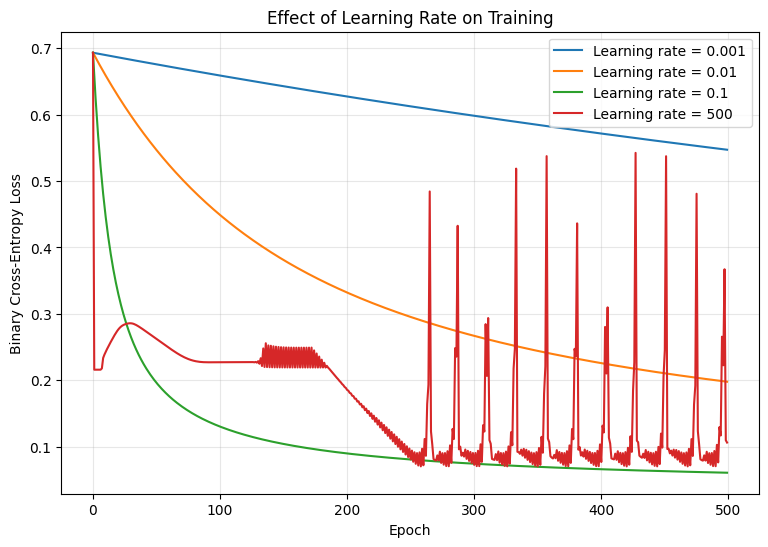

In [ ]:
learning_rates = [0.001, 0.01, 0.1, 500]

plt.figure(figsize=(9, 6))

for lr in learning_rates:
    _, _, losses = train_logistic_regression(
        X_train_scaled,
        y_train,
        learning_rate=lr,
        epochs=500
    )

    plt.plot(
        losses,
        label=f"Learning rate = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Effect of Learning Rate on Training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 23. Experiment: Change the classification threshold

The model predicts a probability, not directly a class.

Try thresholds such as 0.3, 0.5, and 0.7 and observe how accuracy changes.

In [ ]:
thresholds = [0.3, 0.5, 0.7]

for threshold in thresholds:
    predictions = (y_test_prob >= threshold).astype(int)
    acc = accuracy(y_test, predictions)

    print(
        f"Threshold = {threshold:.1f} | "
        f"Accuracy = {acc * 100:.2f}%"
    )

Threshold = 0.3 | Accuracy = 97.50%
Threshold = 0.5 | Accuracy = 100.00%
Threshold = 0.7 | Accuracy = 97.50%


## 24. Final model summary

Print the learned parameters and final performance.

In [ ]:
print("=" * 45)
print("LOGISTIC REGRESSION FROM SCRATCH")
print("=" * 45)

print("Weights:", w)
print("Bias:", b)

print(f"Training Accuracy       : {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy        : {test_accuracy * 100:.2f}%")
print(f"Training Cross-Entropy  : {train_loss:.6f}")
print(f"Testing Cross-Entropy   : {test_loss:.6f}")

print("=" * 45)

LOGISTIC REGRESSION FROM SCRATCH
Weights: [3.10139488 2.99534463]
Bias: 0.12326203313099875
Training Accuracy       : 99.38%
Testing Accuracy        : 100.00%
Training Cross-Entropy  : 0.049259
Testing Cross-Entropy   : 0.040259


## Lab Questions / Exercises

1. What is the purpose of the sigmoid function in logistic regression?
2. Why can we interpret the sigmoid output as a probability?
3. What happens to the Cross-Entropy loss when the model predicts a probability close to 0 for an actual class 1 sample?
4. Why do we use `log` in Binary Cross-Entropy loss?
5. What is the role of the learning rate?
6. What happens if the learning rate is too small?
7. What happens if the learning rate is too large?
8. Why are the gradients divided by the number of training samples?
9. What does the decision boundary represent?
10. Change the number of training epochs to 100, 500, 1000, and 5000. Compare the loss and accuracy.
11. Change the dataset so that the two classes overlap more. What happens to the accuracy?
12. Try different learning rates and identify a suitable value.